In [1]:
import shutil
import os
import stat

directory = 'transformers'

# Function to change permissions and retry
def remove_readonly(func, path, _):
    os.chmod(path, stat.S_IWRITE)
    func(path)


# Check if directory exists
if os.path.exists(directory):
    shutil.rmtree(directory, onerror=remove_readonly)
    print(f"{directory} has been removed.")
else:
    print(f"{directory} does not exist.")


transformers does not exist.


In [2]:
!git clone https://github.com/huggingface/transformers.git

Cloning into 'transformers'...
fatal: write error: No space left on device
fatal: fetch-pack: invalid index-pack output


In [3]:
!pip install diffusers
!pip install sentence-transformers
!pip install torch
!pip install pot

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install accelerate

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install tf-keras

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install ipywidgets --upgrade

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu118



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import torch
print(torch.cuda.is_available())  
print(torch.version.cuda)  

True
11.8


In [12]:
from diffusers import DiffusionPipeline, StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
import torch
from PIL import Image
import requests
from io import BytesIO

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from sentence_transformers import SentenceTransformer

import os

from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
from PIL import Image
from IPython.display import display, Image as Image2
import sys
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests
import cv2
from sklearn.decomposition import TruncatedSVD

from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
from matplotlib import transforms
import torch
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from itertools import chain, combinations
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import wasserstein_distance
from gensim.models import KeyedVectors
from gensim.downloader import load as api_load
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import cdist
from transformers import AutoTokenizer, AutoModel
import torch
import tensorflow as tf
from gensim.models import KeyedVectors
from torch import Generator
import warnings
warnings.filterwarnings('ignore')


In [13]:
import torch
torch.cuda.empty_cache()

In [14]:
#Instruct PIX2PIX
# Initialize the model and pipeline
model_name = "timbrooks/instruct-pix2pix"
pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(model_name, torch_dtype=torch.float16, force_download=True)
device = "cuda"
pipe.to(device)

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionInstructPix2PixPipeline {
  "_class_name": "StableDiffusionInstructPix2PixPipeline",
  "_diffusers_version": "0.30.3",
  "_name_or_path": "timbrooks/instruct-pix2pix",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [15]:
#Dinov2
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = AutoModel.from_pretrained("facebook/dinov2-base")
#Word2Vec model
model_path_bin = r'C:\users\903866\OneDrive - hull.ac.uk\Desktop\image datasets\GoogleNews-vectors-negative300.bin'
model_txt = KeyedVectors.load_word2vec_format(model_path_bin, binary=True)


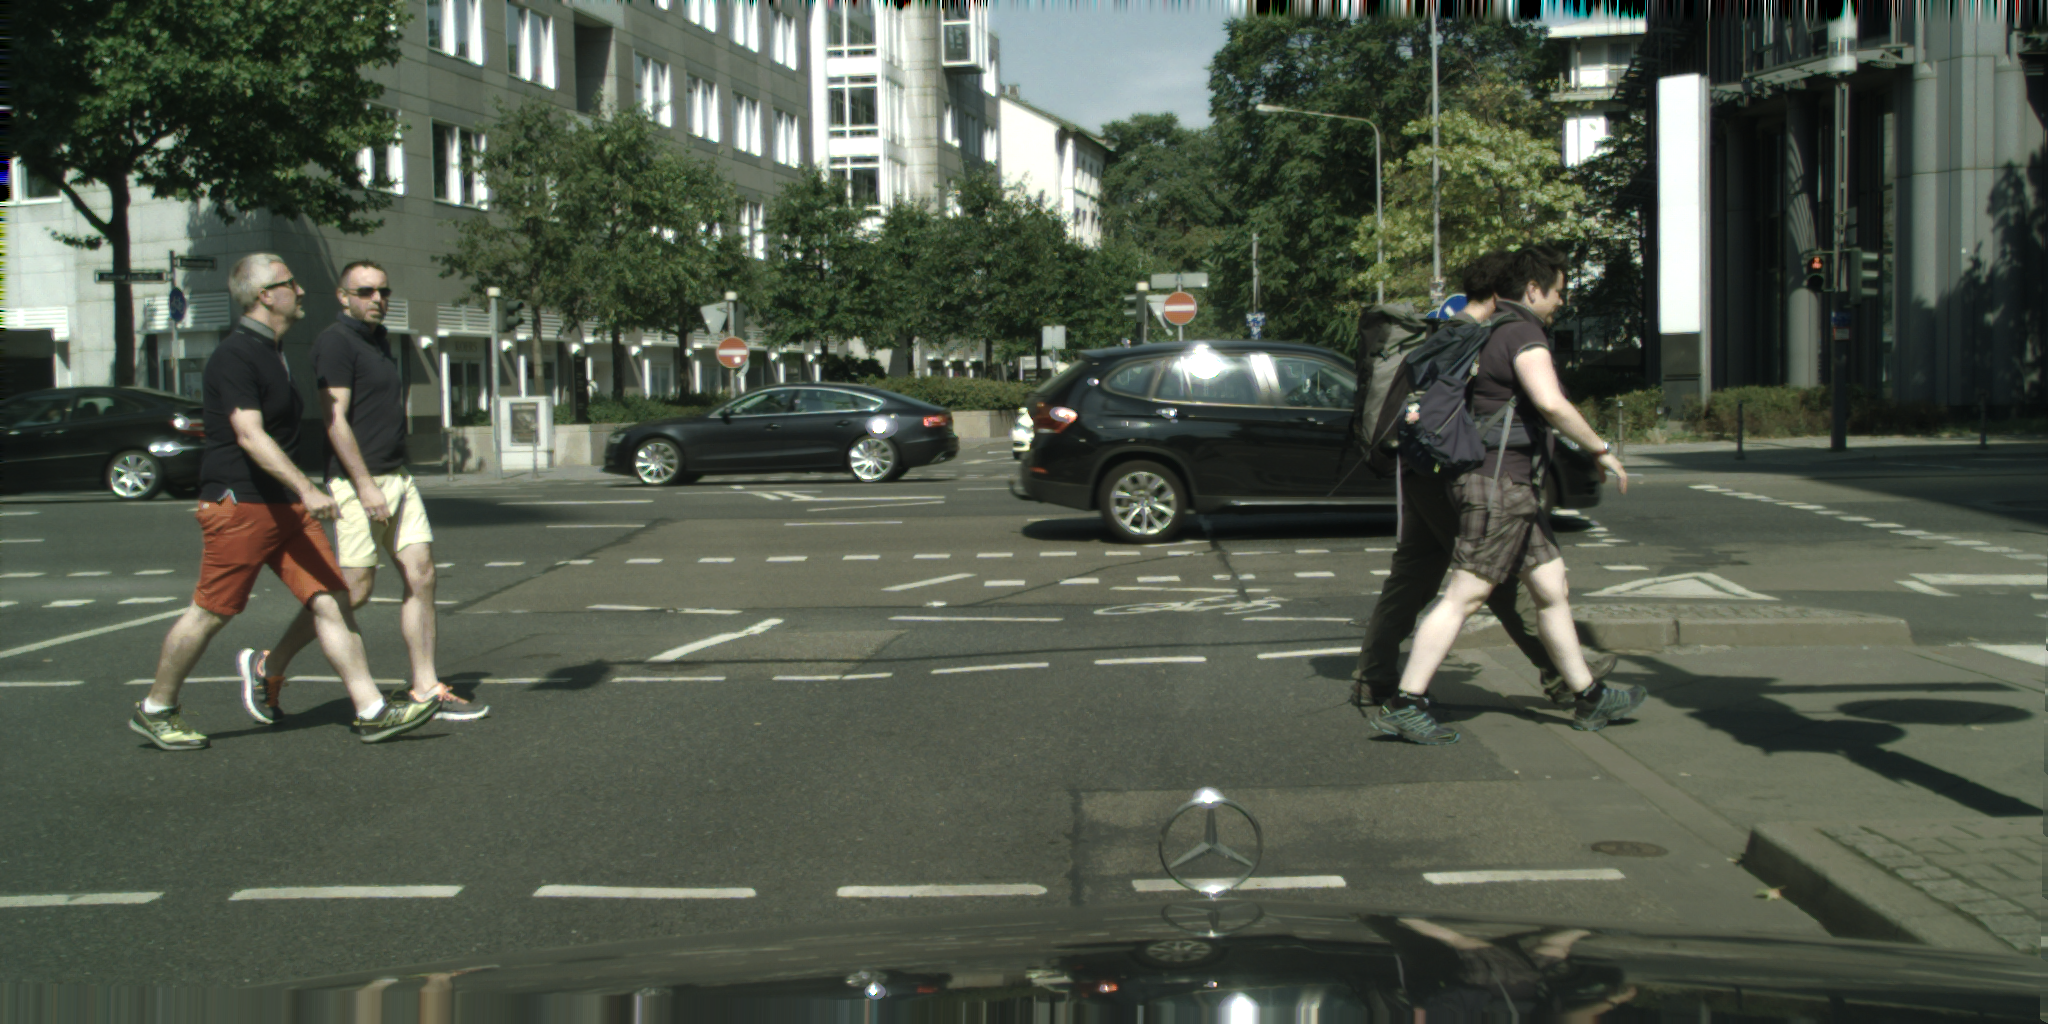

In [16]:
# Load the initial image
url = r"C:\users\903866\OneDrive - hull.ac.uk\Desktop\frankfurt_000000_014480_leftImg8bit.png"
init_image = Image.open(url)
display(init_image)


In [17]:
cfg_image = 9 # This controls how much the output should resemble the original image
cfg_text = 1.15 # This controls how much the output should follow the text prompt

In [18]:
prompt = "Transform the weather to snowy"
words = prompt.split()
words

['Transform', 'the', 'weather', 'to', 'snowy']

In [22]:
def extract_image_embedding(image, processor, model):
    """Extract embeddings from an image using the DINOv2 model."""
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embeddings

# Set initial Wasserstein distance to a large number
WD_dist_init = float('inf')

# Path to save generated images on your local system
output_path = "D:\\test1\\orig.png"


# Repeat generation process until Wasserstein distance is less than 0.1
while WD_dist_init > 0.07:
    # Generate the image
    orig_image = pipe(
        prompt=prompt, 
        image=init_image, 
        cfg_image=cfg_image, 
        cfg_text=cfg_text).images[0]
    
    # Extract embeddings for the original image and initial image
    orig_embedding = extract_image_embedding(orig_image, processor, model)
    init_embedding = extract_image_embedding(init_image, processor, model)
    
    # Calculate Wasserstein distance between the embeddings
    WD_dist_init = wasserstein_distance(orig_embedding, init_embedding)

    print(f'Wasserstein distance: {WD_dist_init}')

    # Save and display the image only if the distance is acceptable
    if WD_dist_init <= 0.07:
        # Save the generated image to the local path
        orig_image.save(output_path)
        print(f"Image saved at: {output_path}")
        
        # Display the image if you're working in an environment where you can visualize it
        # You might need to remove this in VSCode, or use an external viewer
        orig_image.show()

print("Image generation complete with acceptable Wasserstein distance!")


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Set random seeds for reproducibility
seed = 1024
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU
torch.backends.cudnn.deterministic = True  # Ensure reproducibility for cuDNN
torch.backends.cudnn.benchmark = False  # Disable optimized path for reproducibility
generator = torch.Generator().manual_seed(seed)

def perturb_text(text_list, perturbation, rng):
    # Select words based on the perturbation flag (1 means include)
    perturbed_list_initial = [item for item, flag in zip(text_list, perturbation) if flag == 1 and item.strip() != ""]
    
    # If no words were selected, we force select at least one word
    if len(perturbed_list_initial) < 1:
        additional_words_needed = 1
        available_words = [item for item in text_list if item.strip() != ""]
        additional_words = rng.choice(available_words, additional_words_needed, replace=False)
        perturbed_list = perturbed_list_initial + list(additional_words)
    else:
        perturbed_list = perturbed_list_initial
    
    return perturbed_list

# Assuming `prompt` and other variables are predefined
prompt = "Transform the weather to snowy"  # Example prompt
words = prompt.split()
text_list = words.copy()

num_perturb = 30
num_words = len(words)

Responses = []
Perturbations = []
unique_perturbations = set()
rng = np.random.default_rng(seed)

while len(unique_perturbations) < num_perturb:
    # Generate a random perturbation and ensure it selects at least one word
    while True:
        perturbation = tuple(rng.binomial(1, 0.5, size=num_words))  # Random perturbation vector
        if sum(perturbation) > 0:  # Ensure at least one word is selected
            break
    
    # Check for uniqueness
    if perturbation not in unique_perturbations:
        unique_perturbations.add(perturbation)
        perturbed_txt = perturb_text(text_list, perturbation, rng)
        corpus = ' '.join(perturbed_txt)
        Responses.append(corpus)  # Store the unique perturbed text
        Perturbations.append(perturbation)  # Store the perturbation vector
        print(f"Perturbation: {perturbation}, Perturbed Text: {corpus}")


Perturbation: (0, 0, 0, 1, 1), Perturbed Text: to snowy
Perturbation: (0, 1, 1, 1, 0), Perturbed Text: the weather to
Perturbation: (1, 0, 1, 0, 1), Perturbed Text: Transform weather snowy
Perturbation: (1, 0, 1, 1, 0), Perturbed Text: Transform weather to
Perturbation: (1, 1, 1, 0, 0), Perturbed Text: Transform the weather
Perturbation: (1, 0, 0, 0, 0), Perturbed Text: Transform
Perturbation: (1, 1, 1, 1, 1), Perturbed Text: Transform the weather to snowy
Perturbation: (1, 1, 0, 0, 1), Perturbed Text: Transform the snowy
Perturbation: (0, 0, 0, 1, 0), Perturbed Text: to
Perturbation: (1, 0, 0, 0, 1), Perturbed Text: Transform snowy
Perturbation: (1, 1, 1, 0, 1), Perturbed Text: Transform the weather snowy
Perturbation: (1, 1, 0, 0, 0), Perturbed Text: Transform the
Perturbation: (1, 1, 0, 1, 0), Perturbed Text: Transform the to
Perturbation: (0, 0, 1, 1, 0), Perturbed Text: weather to
Perturbation: (0, 1, 0, 0, 1), Perturbed Text: the snowy
Perturbation: (0, 1, 1, 1, 1), Perturbed Tex

In [ ]:
epsilon = 1e-6  # A small value to prevent division by zero
WD_dists_generated_vs_orig = []  # List to store Wasserstein distances

for i, perturbation in enumerate(Perturbations):
    # Generate new text for each perturbation
    perturbed_txt = perturb_text(text_list, perturbation, rng)
    corpus = ' '.join(perturbed_txt)
    
    # Set initial Wasserstein distances for generated image
    WD_dist_generated = float('inf')
    WD_dist_generated_vs_orig_value = float('inf')  # Distance between generated_image and orig_image (temporarily stored inside the loop)

    # Repeat generation process
    while WD_dist_generated > 0.07:  
        # Generate the original image (once, if not already generated)
        orig_image = pipe(
            prompt=corpus,  # Use the perturbed text
            image=init_image, 
            cfg_image=cfg_image, 
            cfg_text=cfg_text).images[0]

        # Generate another image (generated image)
        generated_image = pipe(
            prompt=corpus,  # Use the perturbed text
            image=init_image, 
            cfg_image=cfg_image, 
            cfg_text=cfg_text).images[0]

        # Extract embeddings for the generated image, original image, and initial image
        generated_embedding = extract_image_embedding(generated_image, processor, model)
        init_embedding = extract_image_embedding(init_image, processor, model)
        orig_embedding = extract_image_embedding(orig_image, processor, model)

        # Calculate Wasserstein distance between generated image and initial image
        WD_dist_generated = wasserstein_distance(generated_embedding, init_embedding)

        # If the distance is greater than 0.1, the image is regenerated and no further calculations are done
        if WD_dist_generated > 0.07:
            print(f"Distance too large (WD_dist_generated = {WD_dist_generated}), regenerating image...")
            continue  # Go back to the beginning of the loop to regenerate the image

        # Calculate Wasserstein distance between generated image and original image
        WD_dist_generated_vs_orig_value = wasserstein_distance(generated_embedding, orig_embedding)

        # Store the Wasserstein distance between the generated image and the original image
        WD_dists_generated_vs_orig.append(WD_dist_generated_vs_orig_value)

        # Display the Wasserstein distances
        print(f"Perturbation {i + 1}:")
        print(f'Wasserstein distance (generated vs init): {WD_dist_generated}')
        print(f'Wasserstein distance (generated vs orig): {WD_dist_generated_vs_orig_value}')

        # Display the image only if the distance is acceptable
        plt.figure(figsize=(8, 8))
        plt.imshow(generated_image)
        plt.title(f"Perturbed Text: {corpus}", fontsize=12)
        plt.axis('off')  # Remove the axes
        plt.show()

        # Save the image to the output path if the distance is acceptable
        print(f"Image generation {i + 1} complete with acceptable Wasserstein distance!")
        break  # Exit the loop if the image is acceptable


NameError: name 'Perturbations' is not defined

In [ ]:
wmd_scores = {}
all_texts = [prompt] + Responses  # Include the original text and all perturbed texts
for idx, text in enumerate(all_texts[1:]):  # Exclude the original text
    wmd_score = model_txt.wmdistance(all_texts[0], text)  # Compute WMD
    wmd_scores[f"Original vs Perturbed {idx+1}"] = wmd_score

# Display the WMD scores
print("WMD Scores:\n")
for key, value in wmd_scores.items():
    print(f"{key}: {value:.4f}")

WMD Scores:

Original vs Perturbed 1: 0.4837
Original vs Perturbed 2: 0.4282
Original vs Perturbed 3: 0.1444
Original vs Perturbed 4: 0.1285
Original vs Perturbed 5: 0.1992
Original vs Perturbed 6: 0.4705
Original vs Perturbed 7: 0.0000
Original vs Perturbed 8: 0.1782
Original vs Perturbed 9: 0.7612
Original vs Perturbed 10: 0.3623
Original vs Perturbed 11: 0.0692
Original vs Perturbed 12: 0.2396
Original vs Perturbed 13: 0.2029
Original vs Perturbed 14: 0.3564
Original vs Perturbed 15: 0.2570
Original vs Perturbed 16: 0.2352
Original vs Perturbed 17: 0.3011
Original vs Perturbed 18: 0.1614
Original vs Perturbed 19: 0.4842
Original vs Perturbed 20: 0.2812
Original vs Perturbed 21: 0.0988
Original vs Perturbed 22: 0.2028
Original vs Perturbed 23: 0.6913
Original vs Perturbed 24: 0.2609
Original vs Perturbed 25: 0.2398
Original vs Perturbed 26: 0.1622
Original vs Perturbed 27: 0.5488
Original vs Perturbed 28: 0.2008
Original vs Perturbed 29: 0.5018
Original vs Perturbed 30: 0.6162


In [ ]:
wmd_scores = {}
all_texts = [prompt] + Responses  # Include the original text (prompt) and all responses (perturbed texts)

for idx, text in enumerate(Responses):  # Loop through all perturbed texts (Responses)
    wmd_score = model_txt.wmdistance(prompt, text)  # Compute WMD between prompt and perturbed text
    wmd_scores[f"Original vs Perturbed {idx+1}"] = wmd_score

# Display the WMD scores
print("WMD Scores:\n")
for key, value in wmd_scores.items():
    print(f"{key}: {value:.4f}")

# Assigning WMD scores to a variable 'distances' for future use
distances = wmd_scores


WMD Scores:

Original vs Perturbed 1: 0.4837
Original vs Perturbed 2: 0.4282
Original vs Perturbed 3: 0.1444
Original vs Perturbed 4: 0.1285
Original vs Perturbed 5: 0.1992
Original vs Perturbed 6: 0.4705
Original vs Perturbed 7: 0.0000
Original vs Perturbed 8: 0.1782
Original vs Perturbed 9: 0.7612
Original vs Perturbed 10: 0.3623
Original vs Perturbed 11: 0.0692
Original vs Perturbed 12: 0.2396
Original vs Perturbed 13: 0.2029
Original vs Perturbed 14: 0.3564
Original vs Perturbed 15: 0.2570
Original vs Perturbed 16: 0.2352
Original vs Perturbed 17: 0.3011
Original vs Perturbed 18: 0.1614
Original vs Perturbed 19: 0.4842
Original vs Perturbed 20: 0.2812
Original vs Perturbed 21: 0.0988
Original vs Perturbed 22: 0.2028
Original vs Perturbed 23: 0.6913
Original vs Perturbed 24: 0.2609
Original vs Perturbed 25: 0.2398
Original vs Perturbed 26: 0.1622
Original vs Perturbed 27: 0.5488
Original vs Perturbed 28: 0.2008
Original vs Perturbed 29: 0.5018
Original vs Perturbed 30: 0.6162


In [ ]:
Perturbations = np.vstack(Perturbations)
distance_values = np.array(list(distances.values()))


In [ ]:
WD_dists_generated_vs_orig = np.array(WD_dists_generated_vs_orig)

# Step 1: Compute the inverse of the distances (add a small value to avoid division by zero)
epsilon = 1e-8  # Small value to prevent division by zero
inverse_distances = 1 / (WD_dists_generated_vs_orig + epsilon)

# Step 2: Scale the inverse distances between 0 and 1 (Min-Max scaling)
min_inv = np.min(WD_dists_generated_vs_orig)
max_inv = np.max(WD_dists_generated_vs_orig)

Similarities = (WD_dists_generated_vs_orig - min_inv) / (max_inv - min_inv)

# Now Similarities contains the scaled similarities between 0 and 1
print(Similarities)


[0.50635429 0.18167511 1.         0.42571836 0.1221799  0.02565186
 0.55681415 0.53874966 0.01005395 0.36949909 0.17849402 0.03330576
 0.02030034 0.42015726 0.48055303 0.53355697 0.5204488  0.54229756
 0.47767719 0.45924639 0.54429748 0.54521929 0.04060325 0.40705902
 0.59231744 0.18871328 0.         0.25007369 0.14033268 0.47035987]


In [ ]:
distance_values = np.array(list(distances.values()))

kernel_width = 0.25

# Compute weights based on the distances
weights = np.sqrt(np.exp(-(distance_values ** 2) / (kernel_width ** 2)))

# Fit a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X=Perturbations, y=Similarities, sample_weight=weights)

# Retrieve coefficients from the model
coefficients = linear_model.coef_

# Print the coefficients and weights
print("Coefficients from the Linear Regression model:", coefficients)
print("\nComputed Weights:", weights)


Coefficients from the Linear Regression model: [ 0.00724724 -0.17742901  0.06008283  0.03508296  0.33384243]

Computed Weights: [0.15384139 0.23063125 0.84632991 0.87623908 0.72806159 0.17021403
 1.         0.77565806 0.00970112 0.34983599 0.96241451 0.63170027
 0.71930223 0.36197721 0.58950905 0.64231614 0.48421273 0.81188253
 0.15326352 0.53127772 0.92494091 0.71973172 0.02185674 0.58006216
 0.63117384 0.81029209 0.08988207 0.72419907 0.13338302 0.04794957]


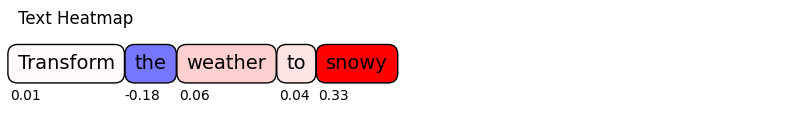

In [ ]:
def plot_text_heatmap(words, scores, title="", width=10, height=0.4, verbose=0, max_word_per_line=20, word_spacing=20, score_fontsize=10, save_path=None):
    fig = plt.figure(figsize=(width, height))
    ax = plt.gca()
    ax.set_title(title, loc='left')
    cmap = plt.cm.ScalarMappable(cmap=plt.cm.bwr)
    cmap.set_clim(0, 1)
    canvas = ax.figure.canvas
    t = ax.transData
    normalized_scores = 0.5 * scores / np.max(np.abs(scores)) + 0.5
    loc_y = -0.2
    for i, (token, score) in enumerate(zip(words, scores)):
        *rgb, _ = cmap.to_rgba(normalized_scores[i], bytes=True)
        color = '#%02x%02x%02x' % tuple(rgb)
        text = ax.text(0.0, loc_y, token, bbox={'facecolor': color, 'pad': 5.0, 'linewidth': 1, 'boxstyle': 'round,pad=0.5'}, transform=t, fontsize=14)
        text.draw(canvas.get_renderer())
        ex = text.get_window_extent()
        score_text = ax.text(0.01, loc_y - 1, f"{score:.2f}", transform=t, fontsize=score_fontsize, ha='center')
        score_text.draw(canvas.get_renderer())
        ex_score = score_text.get_window_extent()
        if (i+1) % max_word_per_line == 0:
            loc_y = loc_y - 2.5
            t = ax.transData
        else:
            t = transforms.offset_copy(text._transform, x=ex.width + word_spacing, units='dots')
    if verbose == 0:
        ax.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    words = "make this image snowy.".split(' ')
# Define the save path for Kaggle output
save_path = save_path = 'C:\\users\\903866\\OneDrive - hull.ac.uk\\Desktop\\result_p1\\text_heatmap.png'


# Call the function with the save_path
plot_text_heatmap(words, coefficients, title="Text Heatmap", save_path=save_path)

In [ ]:
y_true = np.array(Similarities).ravel()
y_pred = linear_model.predict(Perturbations).ravel()

In [ ]:
# Calculate regression metrics
mse = mean_squared_error(y_true, y_pred, sample_weight=weights)
r2 = r2_score(y_true, y_pred, sample_weight=weights)
mae = mean_absolute_error(y_true, y_pred, sample_weight=weights)

# Mean loss (Lm)
mean_loss_f = np.mean(y_true)
mean_loss_g = np.mean(y_pred)
mean_loss = abs(mean_loss_f - mean_loss_g)

# Mean L1 and L2 loss
mean_l1 = np.mean(np.abs(y_true - y_pred))
mean_l2 = np.mean((y_true - y_pred) ** 2)

# Weighted L1 and L2 loss
n = len(y_true)
weighted_l1 = np.sum(weights * np.abs(y_true - y_pred)) / n
weighted_l2 = np.sum(weights * (y_true - y_pred) ** 2) / n

# Weighted R²
f_mean = np.average(y_true, weights=weights)
ss_tot = np.sum(weights * (y_true - f_mean) ** 2)
ss_res = np.sum(weights * (y_true - y_pred) ** 2)
weighted_r2 = 1 - ss_res / ss_tot

# Weighted adjusted R²
p = len(coefficients)
weighted_adj_r2 = 1 - (1 - weighted_r2) * (n - 1) / (n - p - 1)

# Store metrics
metrics = {
    "name": model_name,
    "num_clusters": num_perturb,
    "mse": mse,
    "r2": r2,
    "mae": mae,
    "mean_loss": mean_loss,
    "mean_l1": mean_l1,
    "mean_l2": mean_l2,
    "weighted_l1": weighted_l1,
    "weighted_l2": weighted_l2,
    "weighted_r2": weighted_r2,
    "weighted_adj_r2": weighted_adj_r2
}

# Print fidelity metrics
print(100 * '-')
print('Fidelity:')
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Loss (Lm): {mean_loss}")
print(f"Mean L1 Loss: {mean_l1}")
print(f"Mean L2 Loss: {mean_l2}")
print(f"Weighted L1 Loss: {weighted_l1}")
print(f"Weighted L2 Loss: {weighted_l2}")
print(f"Weighted R-squared (R²ω): {weighted_r2}")
print(f"Weighted Adjusted R-squared (Rˆ²ω): {weighted_adj_r2}")
print(100 * '-')

----------------------------------------------------------------------------------------------------
Fidelity:
Mean Squared Error (MSE): 0.019305327682409276
R-squared (R²): 0.6442191976710174
Mean Absolute Error (MAE): 0.10574606816792347
Mean Loss (Lm): 0.019937257155922317
Mean L1 Loss: 0.10474780494810641
Mean L2 Loss: 0.01824232465617862
Weighted L1 Loss: 0.055382175079102626
Weighted L2 Loss: 0.010110740344206524
Weighted R-squared (R²ω): 0.6442191976710174
Weighted Adjusted R-squared (Rˆ²ω): 0.5700981971858128
----------------------------------------------------------------------------------------------------


In [ ]:
# Calculate the R² score
r2 = r2_score(y_true, y_pred, sample_weight=weights)

# Normalize weights for better visualization (optional)
normalized_weights = np.array(weights) / np.max(weights) * 100  # Scale weights to a reasonable range for point sizes

# Plotting
fig, ax = plt.subplots()
ax.scatter(y_true, y_pred, s=normalized_weights, label='Data points', alpha=0.6)  # Use weights for point sizes

# Determine the range for the perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

# Plotting the Perfect Prediction Line (y = x)
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction Line')

# Set the plot limits to better frame the data
ax.set_xlim([min_val, max_val])
ax.set_ylim([min_val, max_val])

# Labeling the axes
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')

# Title with R² score rounded to two decimal places
ax.set_title(f'Actual vs. Predicted Values\nR²: {r2:.2f}')

# Show legend
ax.legend()
# Define the save path for Kaggle output
save_path = 'C:\users\903866\OneDrive - hull.ac.uk\Desktop\result_p1\plot.png'

# Save the plot to the specified path
plt.savefig(save_path, bbox_inches='tight')
# Show plot
plt.show()